## Multivariate VAR: Pre-Crisis and No-Crisis Counterfactual

This notebook does the following:

- transform the series to stationarity;
- test stationarity;
- select the VAR lag order with AIC;
- fit one VAR model;
- test Granger predictability;
- diagnose the fitted VAR;
- evaluate fixed-origin and rolling forecasts;
- examine impulse responses and forecast error variance decomposition;
- refit using all information through 22 September 2022;
- generate the no-crisis multivariate counterfactual from 23 September onward.

#### Data and VAR Variables

The multivariate system uses daily Bank of England data from 2014–2024 and combines the sterling–US dollar **spot exchange rate** with UK gilt yields at three maturities:

- **XUDLGBD** — Spot exchange rate, Sterling into US$
- **IUDSNZC** — 5-year nominal zero-coupon gilt yield
- **IUDMNZC** — 10-year nominal zero-coupon gilt yield
- **IUDLNZC** — 20-year nominal zero-coupon gilt yield

A spot exchange rate is the market exchange rate for immediate currency exchange. The 5-, 10- and 20-year variables are separate UK government bond yields representing different points along the gilt yield curve.

For the VAR, the exchange rate is converted into a daily log return,

$$
r^{FX}_t = 100\log\left(\frac{FX_t}{FX_{t-1}}\right),
$$

while the gilt yields are converted into daily changes in basis points,

$$
\Delta y^{(m)}_t =
100\left(y^{(m)}_t-y^{(m)}_{t-1}\right).
$$

The resulting VAR therefore examines the dynamic relationships between daily movements in sterling and changes across the UK gilt yield curve.

The counterfactual gap is **not used as an input to the VAR**. It is calculated only after forecasting:

$$
\text{10-year gap}_t = 100\left(y^{actual}_{10,t} -
y^{VAR\ counterfactual}_{10,t}
\right).
$$

A positive gap means the observed 10-year yield is above the model-based counterfactual, while a negative gap means it is below it.

[Data Source](https://www.bankofengland.co.uk/boeapps/database/FromShowColumns.asp?CategId=6&FromCategoryList=Yes&HighlightCatValueDisplay=Exchange+rate+(spot)+-+Sterling+into+us+dollar&NewMeaningId=RSTRUS&Travel=NIxAZxI3x&utm)

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

SEED = 42
np.random.seed(SEED)

In [7]:
RAW_DIR = Path("data") / "raw" / "multivariate"
PROCESSED_DIR = Path("data") / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Manually downloaded Bank of England dataset
SOURCE_FILE = Path("Bank of England Database VAR.csv")

# Processed dataset that will be created later
PROCESSED_FILE = (
    PROCESSED_DIR
    / "boe_var_multivariate_2014_2024.csv"
)

if not SOURCE_FILE.exists():
    raise FileNotFoundError(
        f"Could not find '{SOURCE_FILE}'. "
        "Place Bank of England Database.csv in the same folder "
        "as this notebook."
    )

raw = pd.read_csv(SOURCE_FILE)

print(f"Loaded Bank of England data from: {SOURCE_FILE}")
print(f"Rows: {len(raw):,}")
print("\nColumns:")
print(raw.columns.tolist())

raw.head()

Loaded Bank of England data from: Bank of England Database VAR.csv
Rows: 2,779

Columns:
['DATE', 'XUDLGBD', 'IUDSNZC', 'IUDMNZC', 'IUDLNZC']


,DATE,XUDLGBD,IUDSNZC,IUDMNZC,IUDLNZC
0,02 Jan 2014,0.6084,1.9782,3.1625,3.7449
1,03 Jan 2014,0.6081,1.9771,3.1579,3.7305
2,06 Jan 2014,0.6093,1.9293,3.1053,3.7073
3,07 Jan 2014,0.6098,1.9185,3.0831,3.6906
4,08 Jan 2014,0.6072,1.9674,3.1140,3.7060


In [8]:
def identify_date_column(columns):
    for c in columns:
        if str(c).strip().lower() in {"date", "dates"}:
            return c
    return columns[0]

date_col = identify_date_column(raw.columns)

rename_map = {date_col: "date"}
for code, short_name in SERIES_CODES.items():
    matching = [c for c in raw.columns if code.lower() in str(c).lower()]
    if matching:
        rename_map[matching[0]] = short_name

data = raw.rename(columns=rename_map).copy()

missing = {"date", *SERIES_CODES.values()} - set(data.columns)
if missing:
    raise ValueError(
        f"Could not identify these expected columns: {missing}. "
        f"Columns found were: {list(raw.columns)}"
    )

data = data[["date", "gbpusd", "yield_5y", "yield_10y", "yield_20y"]].copy()
data["date"] = pd.to_datetime(data["date"], dayfirst=True, errors="coerce")

for c in ["gbpusd", "yield_5y", "yield_10y", "yield_20y"]:
    data[c] = pd.to_numeric(data[c], errors="coerce")

data = (
    data.dropna()
        .sort_values("date")
        .drop_duplicates("date")
        .reset_index(drop=True)
)

data["fx_return_pct"] = 100 * np.log(data["gbpusd"] / data["gbpusd"].shift(1))
data["d5y_bps"] = data["yield_5y"].diff() * 100
data["d10y_bps"] = data["yield_10y"].diff() * 100
data["d20y_bps"] = data["yield_20y"].diff() * 100

data.to_csv(PROCESSED_FILE, index=False)

VAR_COLUMNS = ["fx_return_pct", "d5y_bps", "d10y_bps", "d20y_bps"]

print(f"Observations: {len(data)}")
print(f"Date range: {data['date'].min().date()} to {data['date'].max().date()}")
data.head()

Observations: 2779
Date range: 2014-01-02 to 2024-12-31


,date,gbpusd,yield_5y,yield_10y,yield_20y,fx_return_pct,d5y_bps,d10y_bps,d20y_bps
0,2014-01-02,0.6084,1.9782,3.1625,3.7449,NaN,NaN,NaN,NaN
1,2014-01-03,0.6081,1.9771,3.1579,3.7305,-0.049322,-0.11,-0.46,-1.44
2,2014-01-06,0.6093,1.9293,3.1053,3.7073,0.197142,-4.78,-5.26,-2.32
3,2014-01-07,0.6098,1.9185,3.0831,3.6906,0.082028,-1.08,-2.22,-1.67
4,2014-01-08,0.6072,1.9674,3.1140,3.7060,-0.427281,4.89,3.09,1.54


### Plot the four market series

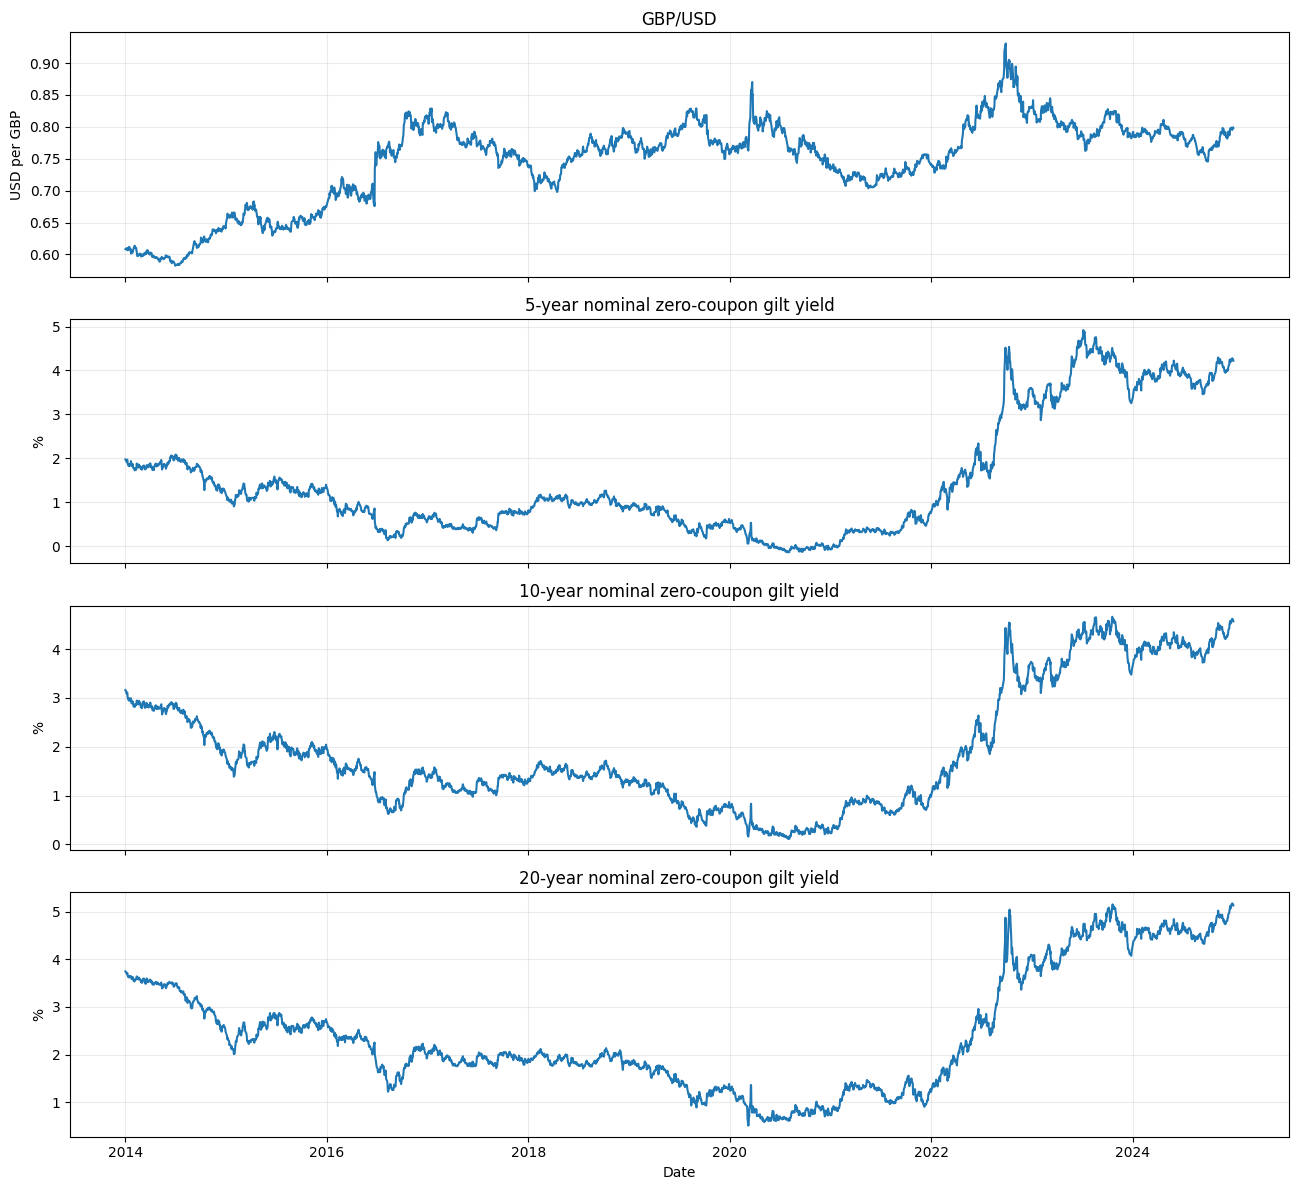

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

axes[0].plot(data["date"], data["gbpusd"])
axes[0].set_ylabel("USD per GBP")
axes[0].set_title("GBP/USD")

axes[1].plot(data["date"], data["yield_5y"])
axes[1].set_ylabel("%")
axes[1].set_title("5-year nominal zero-coupon gilt yield")

axes[2].plot(data["date"], data["yield_10y"])
axes[2].set_ylabel("%")
axes[2].set_title("10-year nominal zero-coupon gilt yield")

axes[3].plot(data["date"], data["yield_20y"])
axes[3].set_ylabel("%")
axes[3].set_title("20-year nominal zero-coupon gilt yield")
axes[3].set_xlabel("Date")

for ax in axes:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

The three gilt-yield series move closely together across the sample, reflecting common movements along the UK yield curve. Yields generally declined from 2014 to 2020 before rising sharply from 2021 onward, with particularly large movements during 2022.

The sterling–US dollar spot exchange-rate series also shows substantial variation over time. These plots are shown in levels for descriptive purposes; the VAR itself uses the stationary transformations of exchange-rate returns and daily gilt-yield changes rather than these level series.

### Pre-crisis train/validation split

In [10]:
CRISIS_START = pd.Timestamp("2022-09-23")
COUNTERFACTUAL_END = pd.Timestamp("2022-10-31")
VALIDATION_SIZE = 60

pre_crisis = data.loc[data["date"] < CRISIS_START].copy().reset_index(drop=True)

train_level = pre_crisis.iloc[:-VALIDATION_SIZE].copy().reset_index(drop=True)
test_level = pre_crisis.iloc[-VALIDATION_SIZE:].copy().reset_index(drop=True)

train_stationary = train_level.dropna(subset=VAR_COLUMNS).copy().reset_index(drop=True)
test_stationary = test_level.dropna(subset=VAR_COLUMNS).copy().reset_index(drop=True)

stationary_sample = train_stationary

print("Pre-crisis observations:", len(pre_crisis))
print("Training observations:", len(train_level))
print("Validation observations:", len(test_level))
print("Training end:", train_level["date"].max().date())
print("Validation start:", test_level["date"].min().date())
print("Validation end:", test_level["date"].max().date())

Pre-crisis observations: 2205
Training observations: 2145
Validation observations: 60
Training end: 2022-06-28
Validation start: 2022-06-29
Validation end: 2022-09-22


### Stationarity tests

In [11]:
def adf_table(df, columns):
    rows = []
    for c in columns:
        s = df[c].dropna().astype(float)
        stat, pvalue, usedlag, nobs, crit, icbest = adfuller(s, autolag="AIC")
        rows.append({
            "series": c,
            "ADF statistic": stat,
            "p-value": pvalue,
            "used lags": usedlag,
            "nobs": nobs,
            "1% critical": crit["1%"],
            "5% critical": crit["5%"],
            "10% critical": crit["10%"],
        })
    return pd.DataFrame(rows)

adf_results = adf_table(stationary_sample, VAR_COLUMNS)
adf_results

,series,ADF statistic,p-value,used lags,nobs,1% critical,5% critical,10% critical
0,fx_return_pct,-19.253637,0.0,5,2138,-3.433412,-2.862893,-2.567490
1,d5y_bps,-34.756329,0.0,1,2142,-3.433407,-2.862890,-2.567489
2,d10y_bps,-34.680365,0.0,1,2142,-3.433407,-2.862890,-2.567489
3,d20y_bps,-33.971977,0.0,1,2142,-3.433407,-2.862890,-2.567489


The ADF test strongly rejects the null hypothesis of a unit root for all four transformed series, with p-values effectively equal to zero.

Therefore, the sterling exchange-rate return and the 5-, 10- and 20-year gilt-yield changes are stationary and suitable for estimation in the VAR in their current transformed form.

### VAR lag-order selection

In [12]:
MAX_LAGS = 10

var_model = VAR(train_stationary[VAR_COLUMNS])
lag_selection = var_model.select_order(maxlags=MAX_LAGS)
print(lag_selection.summary())

selected_orders = lag_selection.selected_orders
BEST_LAG = selected_orders["aic"]

if BEST_LAG is None or BEST_LAG < 1:
    BEST_LAG = 1

print("Selected VAR lag by AIC:", BEST_LAG)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        2.772       2.782       15.99       2.776
1        2.697      2.750*       14.83      2.716*
2        2.686       2.782       14.67       2.721
3       2.670*       2.808      14.44*       2.721
4        2.674       2.855       14.50       2.740
5        2.671       2.894       14.45       2.752
6        2.675       2.941       14.52       2.772
7        2.676       2.984       14.52       2.788
8        2.682       3.033       14.62       2.811
9        2.686       3.079       14.68       2.830
10       2.688       3.124       14.70       2.847
--------------------------------------------------
Selected VAR lag by AIC: 3


AIC and FPE both select a **VAR(3)** model, while BIC and HQIC prefer the more parsimonious VAR(1).

Because AIC is used as the primary selection criterion in this notebook, **VAR(3) is retained**. This means each variable in the system is modelled using the previous three daily observations of all four VAR variables.

### Fit and diagnose the training VAR

In [13]:
var_fit = VAR(train_stationary[VAR_COLUMNS]).fit(BEST_LAG, trend="c")
print(var_fit.summary())

print("\nStable VAR:", var_fit.is_stable())

whiteness_lags = max(10, BEST_LAG + 5)
print("\nResidual whiteness test")
print(var_fit.test_whiteness(nlags=whiteness_lags))

print("\nResidual normality test")
print(var_fit.test_normality())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 30, Aug, 2026
Time:                     10:04:18
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    2.80828
Nobs:                     2141.00    HQIC:                   2.72097
Log likelihood:          -14958.7    FPE:                    14.4485
AIC:                      2.67059    Det(Omega_mle):         14.1028
--------------------------------------------------------------------
Results for equation fx_return_pct
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    0.013142         0.012742            1.031           0.302
L1.fx_return_pct         0.050628         0.022413            2.259           0.024
L1.d5y_bps              -0.014606       

The estimated VAR(3) is **stable**, so its dynamic system is statistically well behaved. Several lagged gilt-yield changes are significant across the 5-, 10- and 20-year equations, while sterling returns show weaker predictive relationships.

However, the residual whiteness test strongly rejects no residual autocorrelation $p<0.001$, meaning VAR(3) does **not fully capture the serial dependence** in the system. Residual normality is also strongly rejected, indicating non-Gaussian innovations.

### Granger-predictability tests

In [14]:
causality_rows = []

tests = [
    ("d10y_bps", ["fx_return_pct"], "GBP/USD return → 10y yield change"),
    ("fx_return_pct", ["d10y_bps"], "10y yield change → GBP/USD return"),
    ("d10y_bps", ["d5y_bps"], "5y yield change → 10y yield change"),
    ("d10y_bps", ["d20y_bps"], "20y yield change → 10y yield change"),
]

for caused, causing, label in tests:
    test = var_fit.test_causality(
        caused=caused,
        causing=causing,
        kind="f"
    )
    causality_rows.append({
        "direction": label,
        "test statistic": float(test.test_statistic),
        "p-value": float(test.pvalue),
        "df": str(test.df),
    })

granger_table = pd.DataFrame(causality_rows)
granger_table

,direction,test statistic,p-value,df
0,GBP/USD return → 10y yield change,1.410209,0.237693,"(3, np.int64(8512))"
1,10y yield change → GBP/USD return,1.702644,0.164149,"(3, np.int64(8512))"
2,5y yield change → 10y yield change,8.408618,0.000014,"(3, np.int64(8512))"
3,20y yield change → 10y yield change,2.574693,0.052143,"(3, np.int64(8512))"


There is **no significant Granger-predictive relationship** between sterling returns and 10-year gilt-yield changes in either direction at the 5% level $p=0.238$ and $p=0.164$.

In contrast, **5-year yield changes significantly Granger-predict 10-year yield changes** $p<0.001$, while the evidence for 20-year yields is borderline $p=0.052$.

These results indicate predictive relationships within the gilt yield curve, but **Granger predictability should not be interpreted as economic causality**.

### Fixed-origin 60-observation validation

The VAR is fitted once at the start of the validation window. It forecasts all 60 unseen market observations without receiving any validation values.

In [15]:
def level_metrics(actual_percent, forecast_percent):
    actual = np.asarray(actual_percent, dtype=float)
    pred = np.asarray(forecast_percent, dtype=float)
    return {
        "MAE_bps": mean_absolute_error(actual, pred) * 100,
        "RMSE_bps": np.sqrt(mean_squared_error(actual, pred)) * 100,
    }

def reconstruct_levels(last_row, stationary_forecast):
    fc = pd.DataFrame(stationary_forecast, columns=VAR_COLUMNS)

    out = pd.DataFrame()
    out["gbpusd"] = float(last_row["gbpusd"]) * np.exp(
        np.cumsum(fc["fx_return_pct"].to_numpy()) / 100
    )
    out["yield_5y"] = float(last_row["yield_5y"]) + np.cumsum(
        fc["d5y_bps"].to_numpy()
    ) / 100
    out["yield_10y"] = float(last_row["yield_10y"]) + np.cumsum(
        fc["d10y_bps"].to_numpy()
    ) / 100
    out["yield_20y"] = float(last_row["yield_20y"]) + np.cumsum(
        fc["d20y_bps"].to_numpy()
    ) / 100
    return out

In [16]:
HORIZON = len(test_level)

stationary_fc = var_fit.forecast(
    y=train_stationary[VAR_COLUMNS].to_numpy()[-BEST_LAG:],
    steps=HORIZON
)

fixed_level_fc = reconstruct_levels(
    train_level.iloc[-1],
    stationary_fc
)

fixed_validation = test_level[
    ["date", "gbpusd", "yield_5y", "yield_10y", "yield_20y"]
].copy().reset_index(drop=True)

for c in ["gbpusd", "yield_5y", "yield_10y", "yield_20y"]:
    fixed_validation[f"VAR_{c}"] = fixed_level_fc[c].to_numpy()

fixed_metrics_10y = pd.Series(
    level_metrics(
        fixed_validation["yield_10y"],
        fixed_validation["VAR_yield_10y"]
    ),
    name="VAR fixed-origin 10y"
)

fixed_metrics_10y

MAE_bps     42.443949
RMSE_bps    47.667716
Name: VAR fixed-origin 10y, dtype: float64

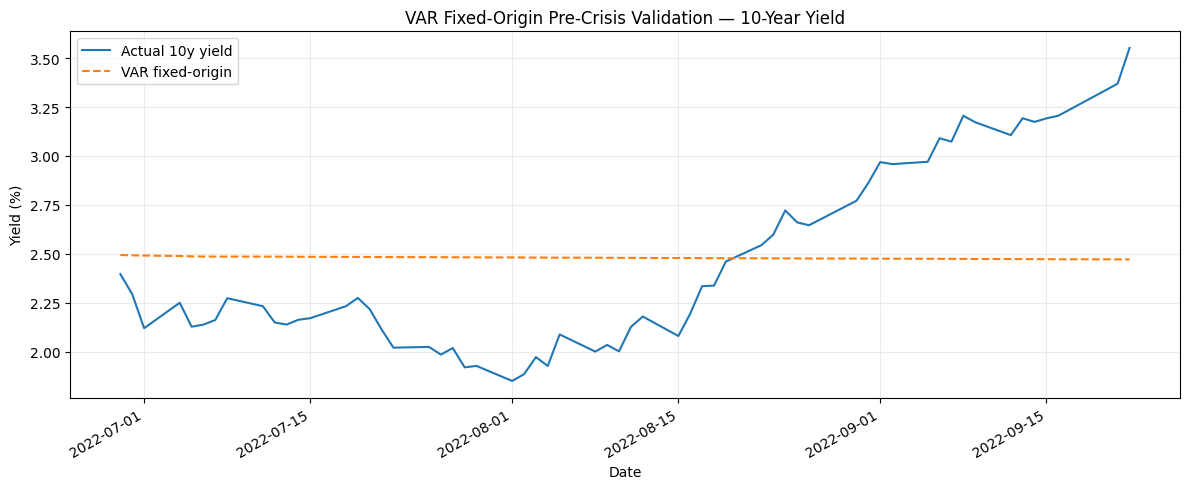

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(fixed_validation["date"], fixed_validation["yield_10y"], label="Actual 10y yield")
ax.plot(fixed_validation["date"], fixed_validation["VAR_yield_10y"], "--", label="VAR fixed-origin")
ax.set_title("VAR Fixed-Origin Pre-Crisis Validation — 10-Year Yield")
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.grid(alpha=0.25)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The fixed-origin VAR forecast remains close to **2.5%** across the 60-day validation window, while the actual 10-year yield first falls and then rises sharply toward **3.55%** by 22 September.

The resulting validation errors are **42.44 bps MAE** and **47.67 bps RMSE**, showing that the VAR does not capture the large upward movement in yields over this period.

This suggests that, despite incorporating sterling and other gilt maturities, the fixed-origin VAR provides limited improvement in predicting the 10-year yield over this horizon.

### Rolling one-step-ahead validation

At each validation date, the VAR is refitted using all observations available strictly before that date. One next-observation forecast is generated, the realised observation is then revealed, and the expanding window moves forward.

In [18]:
rolling_rows = []
train_end_index = len(train_level)

for i in range(train_end_index, len(pre_crisis)):
    history_level = pre_crisis.iloc[:i].copy()
    history_stationary = history_level.dropna(subset=VAR_COLUMNS).copy()

    fit_i = VAR(history_stationary[VAR_COLUMNS]).fit(BEST_LAG, trend="c")

    one_fc = fit_i.forecast(
        history_stationary[VAR_COLUMNS].to_numpy()[-BEST_LAG:],
        steps=1
    )

    one_level = reconstruct_levels(history_level.iloc[-1], one_fc).iloc[0]

    actual = pre_crisis.iloc[i]

    rolling_rows.append({
        "date": actual["date"],
        "actual_gbpusd": actual["gbpusd"],
        "actual_yield_5y": actual["yield_5y"],
        "actual_yield_10y": actual["yield_10y"],
        "actual_yield_20y": actual["yield_20y"],
        "VAR_gbpusd": one_level["gbpusd"],
        "VAR_yield_5y": one_level["yield_5y"],
        "VAR_yield_10y": one_level["yield_10y"],
        "VAR_yield_20y": one_level["yield_20y"],
        "VAR_fx_return_pct": one_fc[0, 0],
        "VAR_d5y_bps": one_fc[0, 1],
        "VAR_d10y_bps": one_fc[0, 2],
        "VAR_d20y_bps": one_fc[0, 3],
    })

rolling_validation = pd.DataFrame(rolling_rows)

rolling_metrics_10y = pd.Series(
    level_metrics(
        rolling_validation["actual_yield_10y"],
        rolling_validation["VAR_yield_10y"]
    ),
    name="VAR rolling one-step 10y"
)

rolling_metrics_10y

MAE_bps     7.297983
RMSE_bps    8.742963
Name: VAR rolling one-step 10y, dtype: float64

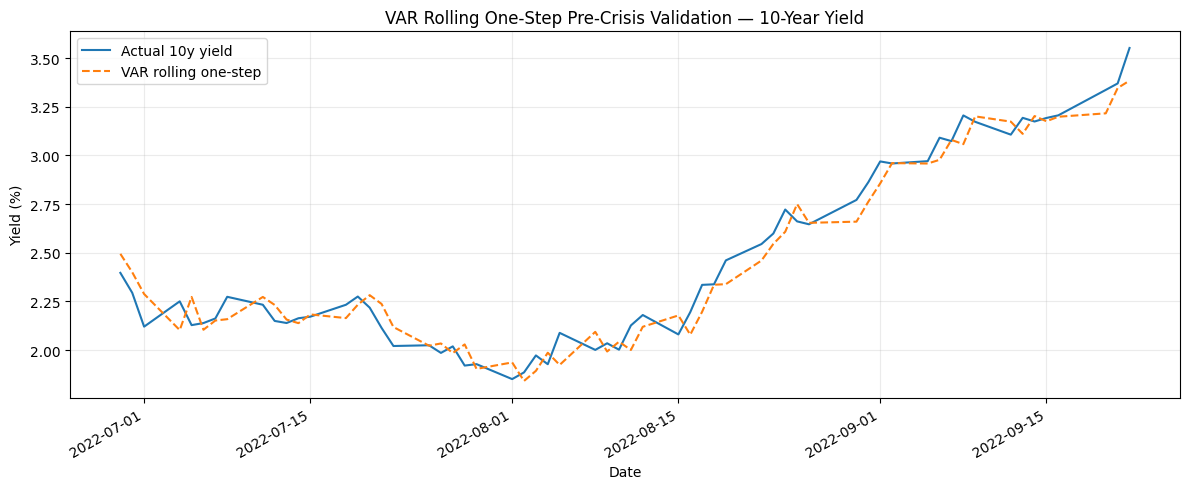

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rolling_validation["date"], rolling_validation["actual_yield_10y"], label="Actual 10y yield")
ax.plot(rolling_validation["date"], rolling_validation["VAR_yield_10y"], "--", label="VAR rolling one-step")
ax.set_title("VAR Rolling One-Step Pre-Crisis Validation — 10-Year Yield")
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.grid(alpha=0.25)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The rolling one-step VAR tracks the actual 10-year yield much more closely than the fixed-origin forecast because the model is re-estimated as each new pre-crisis observation becomes available.

The validation errors fall substantially to **7.30 bps MAE** and **8.74 bps RMSE**, compared with about **42.44 bps MAE** and **47.67 bps RMSE** for the fixed-origin forecast.

This shows that the VAR adapts well to recent market movements at a one-day horizon, but the improvement comes from continuously updating the information set rather than from long-horizon predictive power.

### Impulse-response analysis on the pre-crisis training VAR

The reduced-form IRFs below use `orth=False`, so they do not impose a Cholesky structural ordering. They describe dynamic responses to reduced-form innovations and should not be interpreted as identified causal shocks.

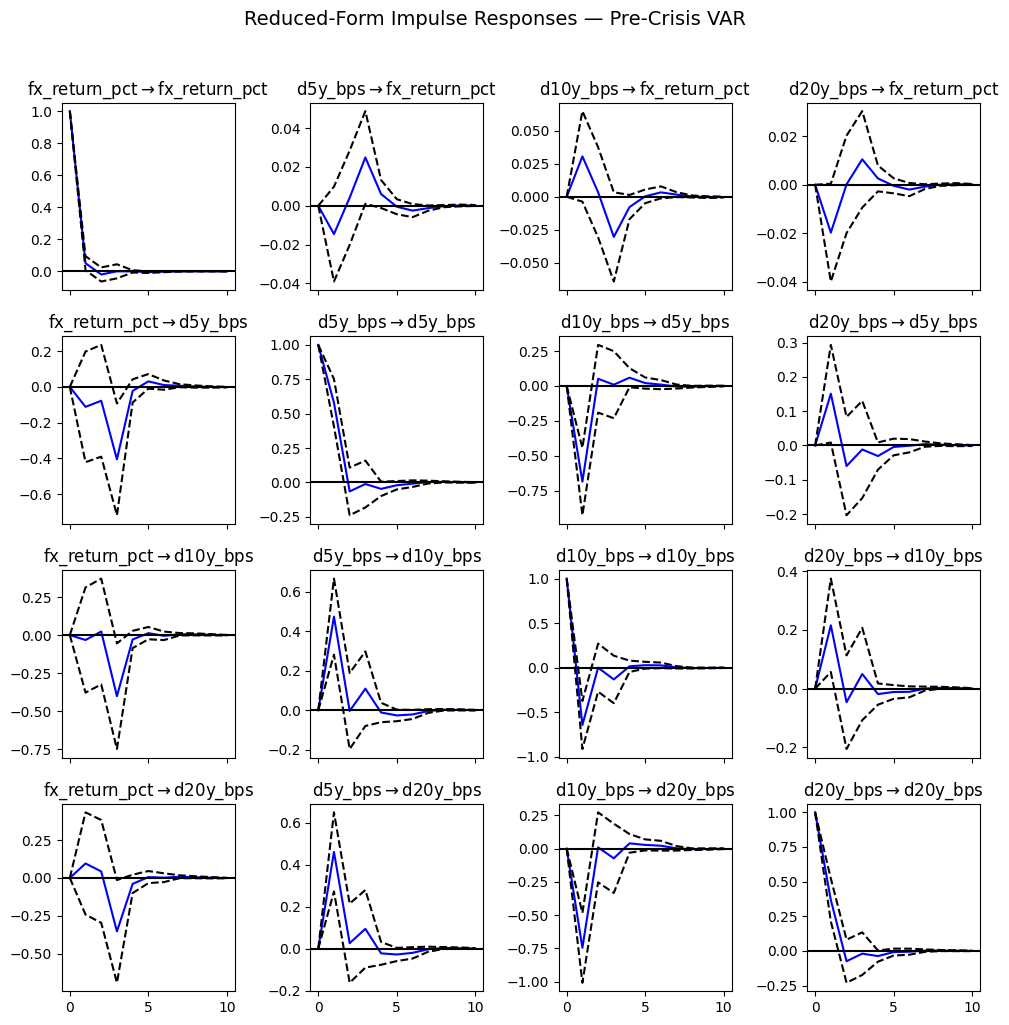

In [20]:
IRF_HORIZON = 10

irf = var_fit.irf(IRF_HORIZON)

fig = irf.plot(orth=False)
fig.suptitle(
    "Reduced-Form Impulse Responses — Pre-Crisis VAR",
    y=1.02,
    fontsize=14
)
plt.tight_layout()
plt.show()

The impulse responses show strong short-run interactions across the gilt yield curve, particularly between the 5-, 10- and 20-year yield changes. Most of these effects decay toward zero within a few trading days.

Responses of gilt yields to sterling-return shocks are comparatively weak and their confidence bands mostly include zero, consistent with the earlier Granger tests.

The VAR suggests that short-run dynamics are driven mainly by interactions within the gilt market rather than by sterling movements. These reduced-form impulse responses describe predictive dynamics and should not be interpreted as causal effects.

### Forecast error variance decomposition

Statsmodels FEVD uses an orthogonalisation of innovations, so the decomposition can depend on variable ordering. The ordering used here is:

`GBP/USD return → 5y yield change → 10y yield change → 20y yield change`.

Treat the FEVD as a sensitivity-based descriptive decomposition rather than a causal attribution.

FEVD for fx_return_pct
     fx_return_pct   d5y_bps  d10y_bps  d20y_bps
0         1.000000  0.000000  0.000000  0.000000
1         0.998244  0.000023  0.000035  0.001699
2         0.995221  0.002990  0.000096  0.001692
3         0.993366  0.003228  0.001242  0.002164
4         0.993256  0.003229  0.001321  0.002193
5         0.993242  0.003242  0.001321  0.002194
6         0.993193  0.003273  0.001323  0.002211
7         0.993187  0.003275  0.001324  0.002214
8         0.993186  0.003275  0.001324  0.002214
9         0.993185  0.003276  0.001324  0.002214

FEVD for d5y_bps
     fx_return_pct   d5y_bps  d10y_bps  d20y_bps
0         0.054387  0.945613  0.000000  0.000000
1         0.053675  0.923390  0.020982  0.001952
2         0.053438  0.923323  0.020987  0.002252
3         0.056200  0.920617  0.020927  0.002257
4         0.056186  0.920531  0.020945  0.002338
5         0.056210  0.920487  0.020965  0.002339
6         0.056211  0.920478  0.020971  0.002339
7         0.056211  0.920477

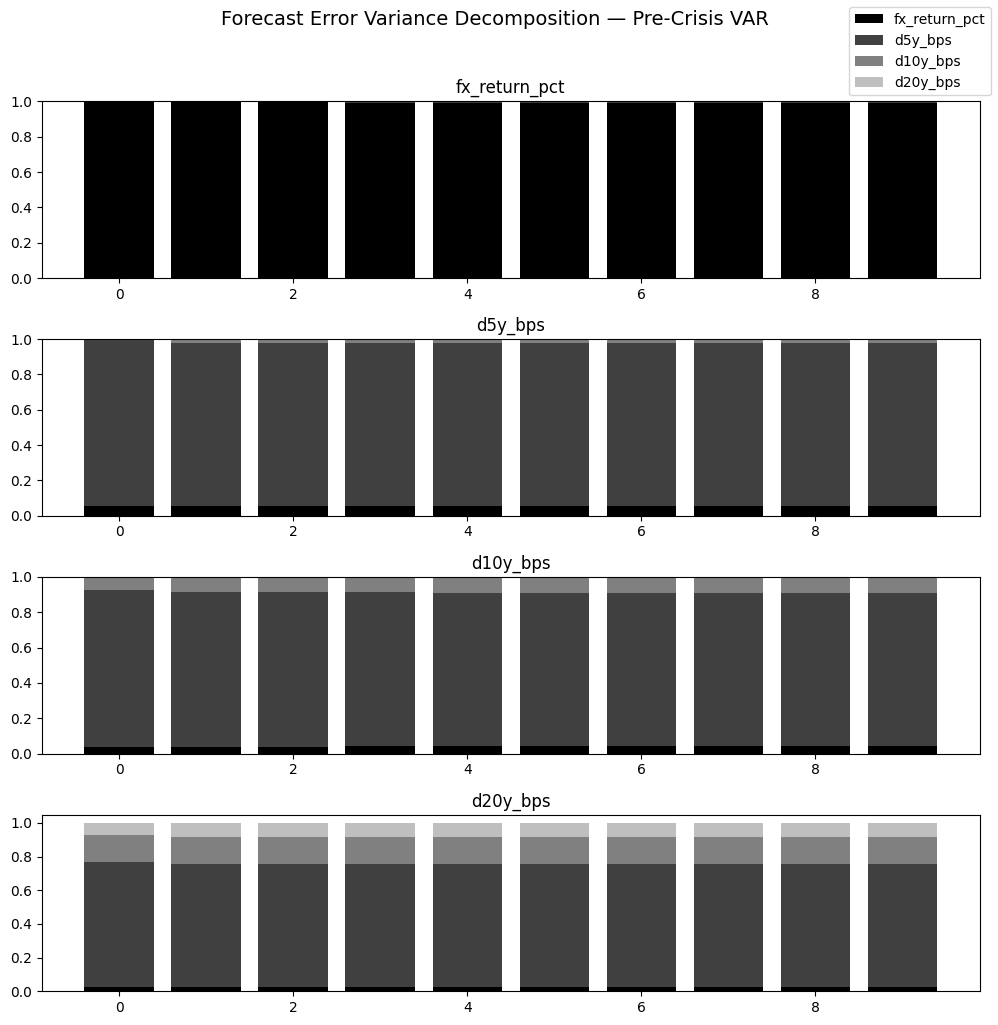

In [21]:
FEVD_HORIZON = 10

fevd = var_fit.fevd(FEVD_HORIZON)
print(fevd.summary())

fig = fevd.plot()
fig.suptitle(
    "Forecast Error Variance Decomposition — Pre-Crisis VAR",
    y=1.02,
    fontsize=14
)
plt.tight_layout()
plt.show()

**Where is the uncertainty coming from?**

The FEVD shows that **GBP/USD forecast uncertainty is almost entirely explained by its own shocks** (about 99%). In contrast, movements within the gilt market are strongly interconnected.

For the **10-year yield change**, roughly **87% of forecast-error variance is attributed to 5-year yield shocks**, about **8.5% to its own shocks**, around **4% to sterling shocks**, and less than **1% to 20-year shocks** at longer horizons.

This reinforces the earlier result that the strongest dynamics are **within the gilt yield curve rather than between sterling and gilt yields**. However, these FEVD percentages depend on the variable ordering used for the Cholesky decomposition, so they should be interpreted as descriptive rather than causal.

### No-crisis VAR counterfactual

The information set is frozen on 22 September 2022. Forecasting begins on 23 September. No crisis-period GBP/USD or gilt-yield observation is fed back into the VAR.

In [23]:
counterfactual_window = data.loc[
    data["date"].between(CRISIS_START, COUNTERFACTUAL_END)
].copy().reset_index(drop=True)

CF_HORIZON = len(counterfactual_window)

cf_stationary = final_var_fit.forecast(
    full_precrisis_stationary[VAR_COLUMNS].to_numpy()[-BEST_LAG:],
    steps=CF_HORIZON
)

cf_levels = reconstruct_levels(pre_crisis.iloc[-1], cf_stationary)

var_no_crisis = counterfactual_window[
    ["date", "gbpusd", "yield_5y", "yield_10y", "yield_20y"]
].copy().reset_index(drop=True)

cf_stationary_df = pd.DataFrame(cf_stationary, columns=VAR_COLUMNS)

for c in ["gbpusd", "yield_5y", "yield_10y", "yield_20y"]:
    var_no_crisis[f"VAR_counterfactual_{c}"] = cf_levels[c].to_numpy()

for c in VAR_COLUMNS:
    var_no_crisis[f"VAR_counterfactual_{c}"] = cf_stationary_df[c].to_numpy()

var_no_crisis["10y_gap_bps"] = (
    var_no_crisis["yield_10y"] - var_no_crisis["VAR_counterfactual_yield_10y"]
) * 100

var_no_crisis.head(15)

,date,gbpusd,yield_5y,yield_10y,yield_20y,VAR_counterfactual_gbpusd,VAR_counterfactual_yield_5y,VAR_counterfactual_yield_10y,VAR_counterfactual_yield_20y,VAR_counterfactual_fx_return_pct,VAR_counterfactual_d5y_bps,VAR_counterfactual_d10y_bps,VAR_counterfactual_d20y_bps,10y_gap_bps
0,2022-09-23,0.9177,3.9648,3.8426,4.0875,0.888843,3.501544,3.566133,3.897829,0.128636,0.594370,1.453279,2.072938,27.646721
1,2022-09-26,0.9270,4.3661,4.1817,4.4720,0.891006,3.495332,3.567870,3.901693,0.243093,-0.621153,0.173748,0.386392,61.382973
2,2022-09-27,0.9282,4.5188,4.4341,4.8707,0.891867,3.493600,3.571904,3.902332,0.096611,-0.173225,0.403417,0.063910,86.219556
3,2022-09-28,0.9307,4.2254,4.0517,4.0178,0.892006,3.490407,3.568421,3.897848,0.015616,-0.319255,-0.348342,-0.448437,48.327898
4,2022-09-29,0.9063,4.3110,4.1210,4.0560,0.892032,3.489953,3.566543,3.895773,0.002836,-0.045438,-0.187753,-0.207510,55.445651
5,2022-09-30,0.8953,4.3172,4.1021,3.9372,0.892046,3.490831,3.566050,3.895171,0.001588,0.087766,-0.049340,-0.060195,53.604992
6,2022-10-03,0.8865,4.1235,3.9766,4.0105,0.892162,3.492001,3.566441,3.895505,0.012995,0.117042,0.039120,0.033409,41.015871
7,2022-10-04,0.8769,4.0157,3.9036,4.1185,0.892321,3.492913,3.566885,3.895881,0.017871,0.091195,0.044375,0.037583,33.671496
8,2022-10-05,0.8893,4.1345,4.0527,4.3022,0.892490,3.493680,3.567246,3.896136,0.018914,0.076707,0.036049,0.025557,48.545447
9,2022-10-06,0.8929,4.2720,4.2134,4.4597,0.892652,3.494370,3.567493,3.896257,0.018106,0.069037,0.024747,0.012006,64.590700


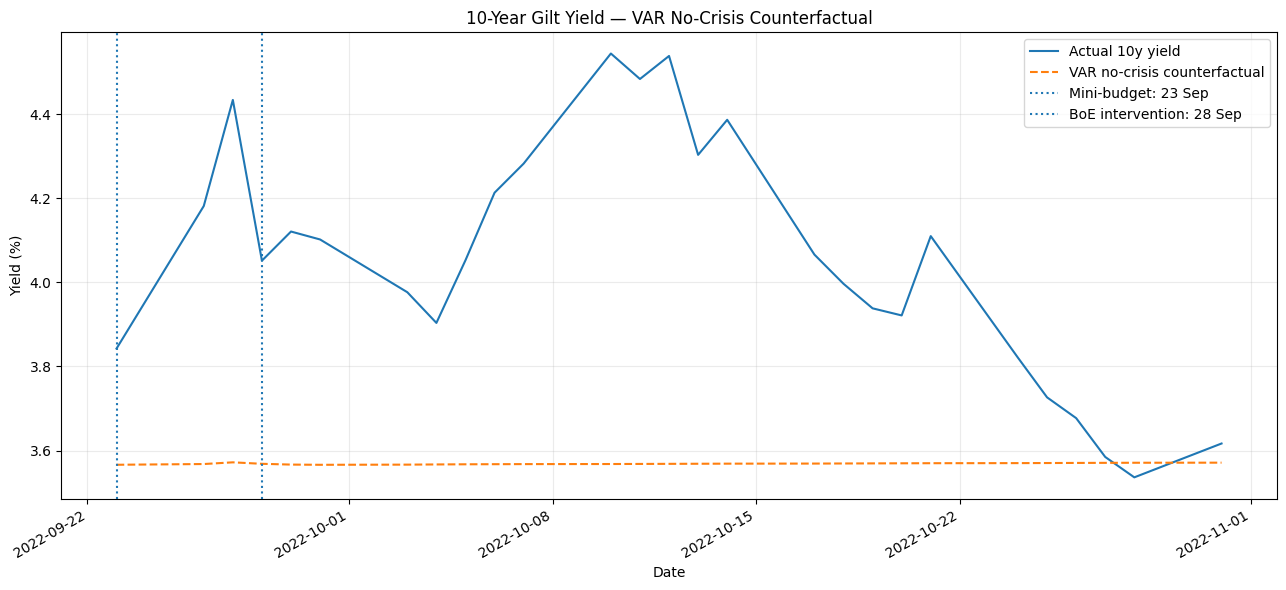

In [24]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(var_no_crisis["date"], var_no_crisis["yield_10y"], label="Actual 10y yield")
ax.plot(
    var_no_crisis["date"],
    var_no_crisis["VAR_counterfactual_yield_10y"],
    "--",
    label="VAR no-crisis counterfactual"
)
ax.axvline(pd.Timestamp("2022-09-23"), linestyle=":", linewidth=1.5, label="Mini-budget: 23 Sep")
ax.axvline(pd.Timestamp("2022-09-28"), linestyle=":", linewidth=1.5, label="BoE intervention: 28 Sep")
ax.set_title("10-Year Gilt Yield — VAR No-Crisis Counterfactual")
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.grid(alpha=0.25)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Conclusion

The pre-crisis **VAR(3)** shows that short-run relationships are strongest **within the gilt yield curve**, particularly between the 5-, 10- and 20-year yield changes, while sterling returns have relatively weak predictive relationships with gilt yields. This is supported by the Granger-predictability tests, impulse responses and FEVD results.

For forecasting, the **fixed-origin VAR performs poorly over the 60-day horizon** $MAE ≈ 42.44 bps$, whereas the **rolling one-step VAR performs substantially better** $MAE ≈ 7.30 bps$, showing that the model is much more effective when continuously updated with recent market information.

Overall, the VAR provides useful evidence of interconnected gilt-market dynamics but limited evidence that sterling movements are an important driver of gilt yields in the pre-crisis sample. The VAR is stable, although residual autocorrelation remains, so the dynamic results should be interpreted with caution and **not as causal relationships**.

In [25]:
OUTPUT_DIR = Path("outputs") / "var_precrisis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

fixed_validation.to_csv(OUTPUT_DIR / "var_fixed_validation.csv", index=False)
rolling_validation.to_csv(OUTPUT_DIR / "var_rolling_validation.csv", index=False)
var_no_crisis.to_csv(OUTPUT_DIR / "var_no_crisis_counterfactual.csv", index=False)

fixed_exog = pd.DataFrame({
    "date": fixed_validation["date"],
    "VAR_fx_return_pct": stationary_fc[:, 0],
    "VAR_d5y_bps": stationary_fc[:, 1],
    "VAR_d20y_bps": stationary_fc[:, 3],
})
fixed_exog.to_csv(OUTPUT_DIR / "var_fixed_validation_exog_for_arimax.csv", index=False)

rolling_exog = rolling_validation[
    ["date", "VAR_fx_return_pct", "VAR_d5y_bps", "VAR_d20y_bps"]
].copy()
rolling_exog.to_csv(OUTPUT_DIR / "var_rolling_validation_exog_for_arimax.csv", index=False)

cf_exog = var_no_crisis[
    ["date", "VAR_counterfactual_fx_return_pct",
     "VAR_counterfactual_d5y_bps", "VAR_counterfactual_d20y_bps"]
].copy()
cf_exog.columns = ["date", "VAR_fx_return_pct", "VAR_d5y_bps", "VAR_d20y_bps"]
cf_exog.to_csv(OUTPUT_DIR / "var_no_crisis_exog_for_arimax.csv", index=False)

with open(OUTPUT_DIR / "var_specification.json", "w") as f:
    json.dump({"best_lag_aic": int(BEST_LAG), "variables": VAR_COLUMNS}, f, indent=2)

print("Saved to:", OUTPUT_DIR.resolve())

Saved to: /Users/qp252008/Downloads/Dissertation/outputs/var_precrisis
